In [1]:
# Cell 1: Notebook Setup
# ----------------------

# Install requirements if necessary (optional)
# !pip install scanpy openai anndata

# Set display options
import scanpy as sc
import warnings
warnings.filterwarnings("ignore")

# Set matplotlib style
sc.settings.verbosity = 2
sc.set_figure_params(figsize=(5, 5), dpi=100)


In [2]:
# Cell 2: Load Dataset
# --------------------

# You can either load your own dataset:
# adata = sc.read_h5ad("your_dataset.h5ad")

# Or use a built-in sample loader from tic
from tic.data import load_xenium_dataset

adata = load_xenium_dataset(dataset='xenium_ffpe_human_breast',n_cells=100000)
adata


Dataset already exists in /Users/zhangjiahao/.cache/tic/xenium_ffpe_human_breast, skipping download.
reading /Users/zhangjiahao/.cache/tic/xenium_ffpe_human_breast/cell_feature_matrix.h5
 (0:00:00)
[✓] Loaded xenium_ffpe_human_breast: 100000 cells × 541 genes.


AnnData object with n_obs × n_vars = 100000 × 541
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'cell_type'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'tissue_id', 'data_level'
    obsm: 'spatial'

In [3]:
DATASET_DESCRIPTION = """
Demonstration of gene expression profiling for formalin-fixed paraffin-embedded (FFPE) human breast samples on the Xenium platform.
The data were generated with the pre-designed Xenium Human Breast Gene Expression Panel (v1) (base panel). The same experiment was also run with a custom add-on panel of 100 genes.
5µm sections from two resected tumor mass tissues:
Infiltrating ductal carcinoma, Ductal carcinoma in situ (from BiolVT)
Invasive lobular carcinoma (from Avaden Biosciences)
The tissues were prepared following the demonstrated protocols Xenium In Situ for FFPE - Tissue Preparation Guide (CG000578) and Xenium In Situ for FFPE Tissues – Deparaffinization & Decrosslinking (CG000580).
Post-instrument processing followed the demonstrated protocol Xenium In Situ Gene Expression - Post-Xenium Analyzer H&E Staining (CG000613). The registered H&E image file is suitable for annotating regions. It may or may not be suitable for more refined exact sub-cellular resolution correspondence due to minute differences in the optics of the microscopy systems. Learn more in the H&E to Xenium DAPI Image Registration with Fiji Analysis Guide.
"""

In [4]:
# Cell 3: Run Full Annotation Pipeline
# ------------------------------------

from tic.annotation import annotate_adata
from utils.config import API_KEY  # You should place your OpenAI API key here

# Run clustering + marker gene extraction + LLM annotation
adata_pred, cluster_annotation = annotate_adata(
    adata=adata,
    assign_params={
        "min_cells": 0,
        "min_genes": 0,
        "n_pca": 50,
        "n_neighbors": 15,
        "resolution": 2.0,
        "n_filter_highly_variable_genes": 2000,
    },
    llm_model_name="openai",
    llm_kwargs={"api_key": API_KEY, "mirror": True},
    dataset_description=(
        DATASET_DESCRIPTION+
        "This dataset contains tumor cells. Please ensure at least one cluster is annotated as tumor."
    ),
    groupby="leiden",
    rank_genes_groups_method="t-test",
    n_genes=10,
    copy=True,
    return_cluster_annotation=True,
)

# Show cluster-to-cell-type mapping
import json
print(json.dumps(cluster_annotation, indent=2))


normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
`n_top_genes` > `adata.n_var`, returning all genes.
    finished (0:00:00)
computing PCA
    with n_comps=50
    finished (0:00:00)
computing neighbors
    using 'X_pca' with n_pcs = 50
    finished (0:00:15)
running Leiden clustering
    finished (0:04:35)
computing UMAP
    finished (0:00:40)
ranking genes


... storing 'cell_type' as categorical
... storing 'feature_types' as categorical
... storing 'genome' as categorical


    finished (0:00:00)
{
  "0": {
    "assigned_cell_type": "Mast cells",
    "reasoning": "High expression of TPSAB1 (tryptase beta-1) and KIT are hallmark mast cell markers. TPSAB1 encodes tryptase, the most abundant protease in mast cell granules; KIT (CD117) is the receptor for stem cell factor, essential for mast cell development."
  },
  "1": {
    "assigned_cell_type": "Luminal epithelial cells",
    "reasoning": "Enrichment of DSP (desmoplakin), GATA3, KRT23, ANKRD30A, FOXA1, and TACSTD2 is characteristic of breast luminal epithelial cells. GATA3 and FOXA1 are transcription factors central to luminal differentiation; ANKRD30A (NY-BR-1) is breast-specific; DSP and TACSTD2 are associated with epithelial junctions."
  },
  "2": {
    "assigned_cell_type": "Luminal epithelial cells",
    "reasoning": "Markers SCD, KRT7, FASN, ERBB2 (HER2), TACSTD2, FOXA1, and GATA3 are highly expressed in luminal epithelial cells. ERBB2 suggests this may include tumor cells from HER2-positive cance

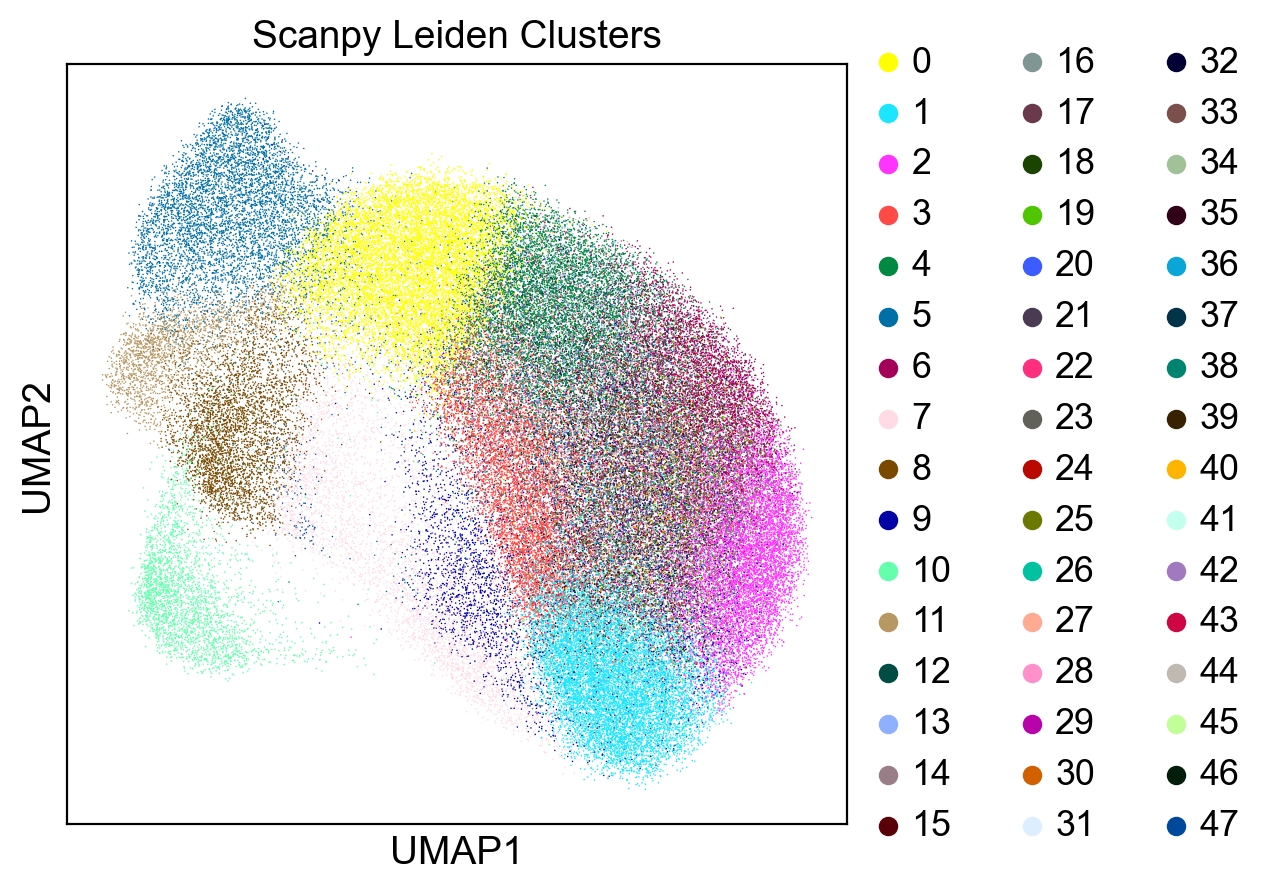

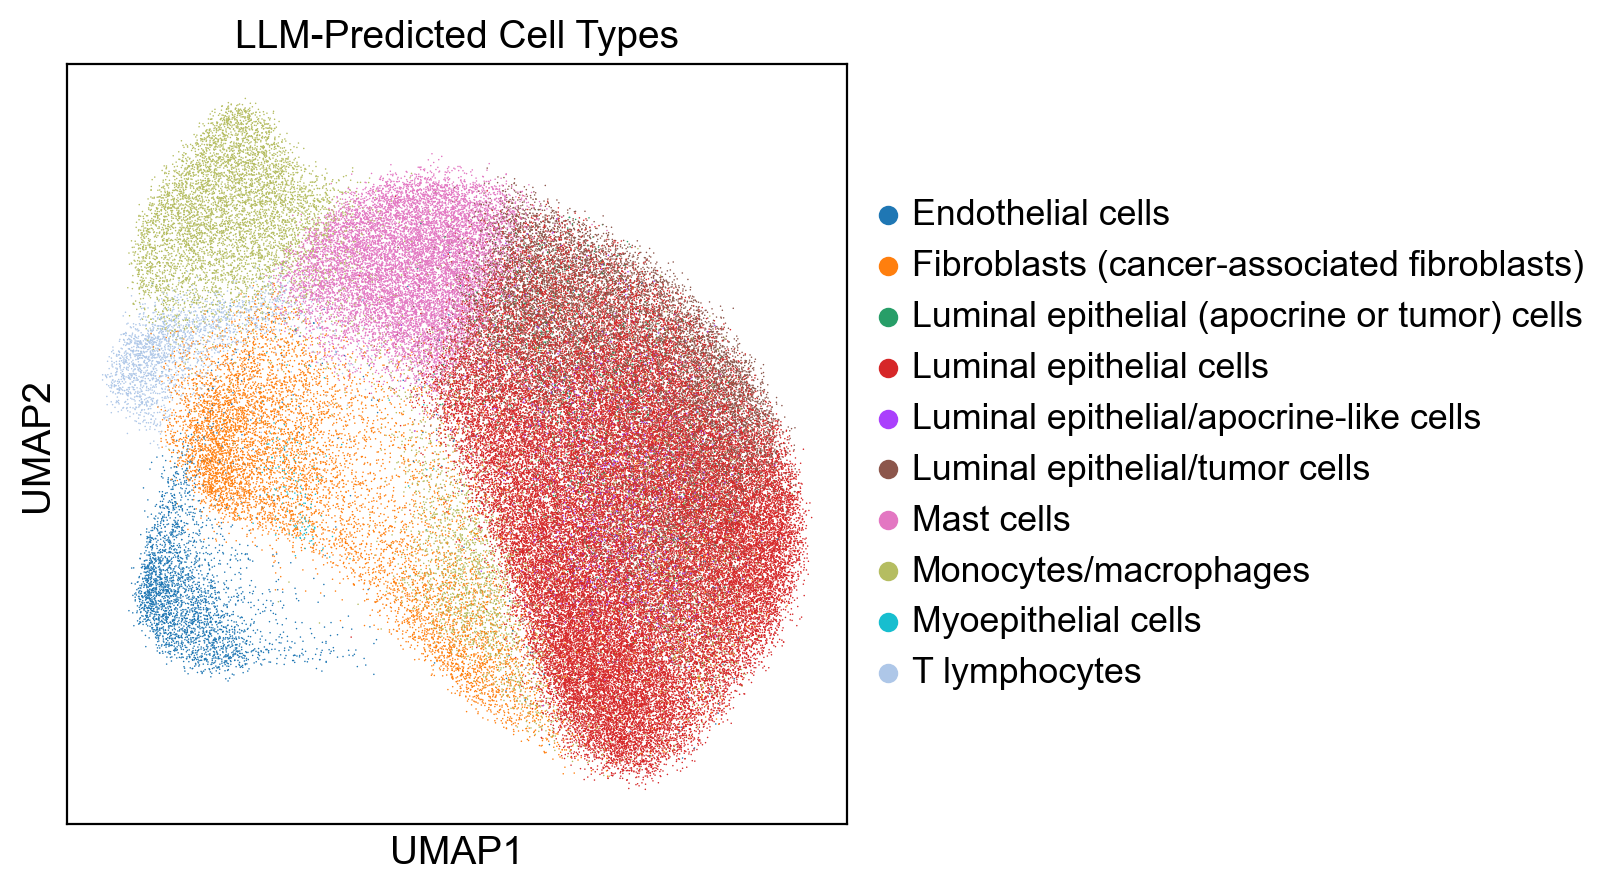

In [5]:
# Cell 4: Visualize Annotation Results
# ------------------------------------

# Plot UMAP colored by original cluster
sc.pl.umap(adata_pred, color=["leiden"], title="Scanpy Leiden Clusters")

# Plot UMAP colored by LLM-predicted cell types
sc.pl.umap(adata_pred, color=["pred_cell_type"], title="LLM-Predicted Cell Types")


In [6]:
# Cell 5: Inspect Marker Genes (Optional)
# ---------------------------------------

# Show top marker genes used for annotation
from tic.annotation import return_top_genes

top_genes = return_top_genes(adata_pred, groupby="leiden", n_genes=5)

# Display in table
for cluster, info in top_genes.items():
    print(f"\nCluster {cluster}")
    for g, score in zip(info["genes"], info["scores"]):
        print(f"  {g:20s} score: {score:.3f}")


ranking genes
    finished (0:00:00)

Cluster 0
  TPSAB1               score: 3.901
  BLANK_0412           score: 1.414
  BLANK_0494           score: 1.041
  BLANK_0385           score: 1.000
  BLANK_0394           score: 1.000

Cluster 1
  DSP                  score: 209.740
  FAM107B              score: 162.237
  ANKRD30A             score: 121.885
  GATA3                score: 112.511
  FOXA1                score: 89.840

Cluster 2
  SCD                  score: 105.132
  KRT7                 score: 103.680
  FASN                 score: 100.510
  TPD52                score: 94.056
  TACSTD2              score: 93.789

Cluster 3
  DSP                  score: 97.214
  GATA3                score: 57.429
  ANKRD30A             score: 56.514
  FAM107B              score: 54.616
  TACSTD2              score: 35.994

Cluster 4
  SCD                  score: 39.730
  KRT7                 score: 36.614
  FASN                 score: 36.463
  TPD52                score: 34.253
  GATA3           